# EfficientNet-B3 Training — 40 Food Classes (v2 Improved)
Improvements over v1:
- EfficientNet-B3 (higher capacity than B0)
- 50 epochs with LR warmup + cosine annealing
- MixUp augmentation (alpha=0.2)
- Label smoothing=0.1
- Palette/transparency PNG fix
- Gradient clipping
- TTA (Test-Time Augmentation) at evaluation
- Saves model_name + image_size in checkpoint

In [ ]:
# ── 1. Install & imports ──────────────────────────────────────────────────
!pip install -q timm

import os, zipfile, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_SIZE  = 300   # B3 native size
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
WARMUP      = 5
MIXUP_ALPHA = 0.2
SEED        = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
print('Device:', DEVICE)

Device: cuda


In [ ]:
# ── 2. Upload & extract dataset ───────────────────────────────────────────
from google.colab import files
print('Upload food_dataset.zip')
uploaded = files.upload()   # upload food_dataset.zip

with zipfile.ZipFile('food_dataset.zip', 'r') as z:
    z.extractall('.')

DATASET_PATH = 'food_dataset'
print('Train classes:', len(os.listdir(f'{DATASET_PATH}/train')))

Upload food_dataset.zip


Saving food_dataset.zip to food_dataset.zip
Train classes: 40


In [ ]:
# ── 3. Dataset with palette/transparency fix ──────────────────────────────
class FoodDataset(Dataset):
    """ImageFolder wrapper that safely converts palette/RGBA images to RGB."""
    def __init__(self, root, transform=None):
        self.dataset      = torchvision.datasets.ImageFolder(root)
        self.transform    = transform
        self.classes      = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        path, label = self.dataset.samples[idx]
        try:
            img = Image.open(path)
            if img.mode in ('P', 'PA'):
                img = img.convert('RGBA')
            img = img.convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        return img, label


train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1),
])
val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = FoodDataset(f'{DATASET_PATH}/train', transform=train_tf)
val_ds   = FoodDataset(f'{DATASET_PATH}/val',   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {NUM_CLASSES} | Train: {len(train_ds)} | Val: {len(val_ds)}')

Classes: 40 | Train: 3034 | Val: 767


In [ ]:
# ── 4. Model — EfficientNet-B3 ────────────────────────────────────────────
model = models.efficientnet_b3(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'EfficientNet-B3 | {NUM_CLASSES} classes | {total_params:.1f}M params')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 68.2MB/s]


EfficientNet-B3 | 40 classes | 10.8M params


In [ ]:
# ── 5. MixUp helper ───────────────────────────────────────────────────────
def mixup_batch(images, labels, alpha=0.2):
    if alpha <= 0:
        return images, labels, labels, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

In [ ]:
# ── 6. Training ───────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / (EPOCHS - WARMUP)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history  = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_acc = 0.0

for epoch in range(EPOCHS):
    # Train
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        imgs, labels_a, labels_b, lam = mixup_batch(imgs, labels, MIXUP_ALPHA)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = lam * criterion(out, labels_a) + (1 - lam) * criterion(out, labels_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss    += loss.item() * imgs.size(0)
        t_correct += (out.argmax(1) == labels_a).sum().item()
        t_total   += labels.size(0)

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out    = model(imgs)
            v_loss += criterion(out, labels).item() * imgs.size(0)
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total   += labels.size(0)

    t_acc  = 100 * t_correct / t_total
    v_acc  = 100 * v_correct / v_total
    lr_now = optimizer.param_groups[0]['lr']
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['train_loss'].append(t_loss / t_total)
    history['val_loss'].append(v_loss / v_total)
    scheduler.step()

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train {t_acc:.2f}% | Val {v_acc:.2f}% | LR {lr_now:.5f}')

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': v_acc,
            'class_names': CLASS_NAMES,
            'image_size': IMAGE_SIZE,
            'model_name': 'efficientnet_b3',
        }, 'food_classifier_best.pth')
        print(f'  -> Saved best (val_acc: {v_acc:.2f}%)')

print(f'\nBest val accuracy: {best_acc:.2f}%')

Epoch 01/50 | Train 14.54% | Val 66.23% | LR 0.00020
  -> Saved best (val_acc: 66.23%)
Epoch 02/50 | Train 34.67% | Val 80.31% | LR 0.00040
  -> Saved best (val_acc: 80.31%)
Epoch 03/50 | Train 38.96% | Val 83.44% | LR 0.00060
  -> Saved best (val_acc: 83.44%)
Epoch 04/50 | Train 31.41% | Val 81.75% | LR 0.00080
Epoch 05/50 | Train 37.84% | Val 81.36% | LR 0.00100
Epoch 06/50 | Train 47.46% | Val 80.44% | LR 0.00100
Epoch 07/50 | Train 44.92% | Val 82.79% | LR 0.00100
Epoch 08/50 | Train 47.63% | Val 80.83% | LR 0.00100
Epoch 09/50 | Train 38.43% | Val 84.22% | LR 0.00099
  -> Saved best (val_acc: 84.22%)
Epoch 10/50 | Train 48.98% | Val 84.22% | LR 0.00098
Epoch 11/50 | Train 41.86% | Val 83.83% | LR 0.00097
Epoch 12/50 | Train 50.20% | Val 84.35% | LR 0.00096
  -> Saved best (val_acc: 84.35%)
Epoch 13/50 | Train 48.78% | Val 84.88% | LR 0.00094
  -> Saved best (val_acc: 84.88%)
Epoch 14/50 | Train 51.88% | Val 84.09% | LR 0.00092
Epoch 15/50 | Train 50.96% | Val 82.14% | LR 0.00090
E

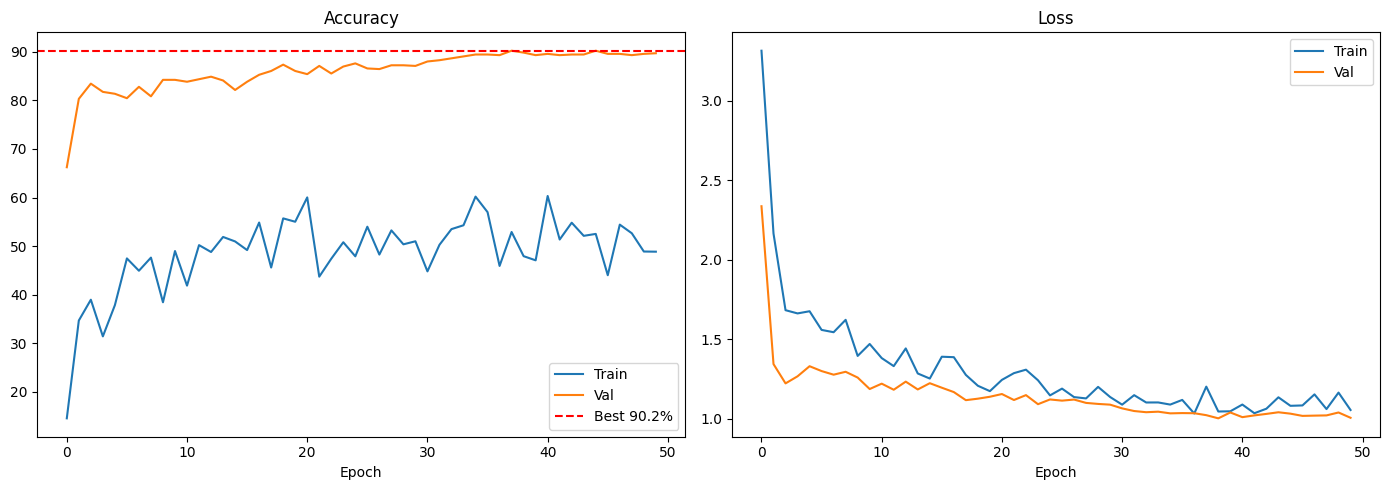

In [ ]:
# ── 7. Plot training curves ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_acc'], label='Train')
ax1.plot(history['val_acc'],   label='Val')
ax1.axhline(y=best_acc, color='r', linestyle='--', label=f'Best {best_acc:.1f}%')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')
ax2.plot(history['train_loss'], label='Train')
ax2.plot(history['val_loss'],   label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
# ── 8. Per-class accuracy analysis ───────────────────────────────────────
from collections import defaultdict

# Reload best model for analysis
ckpt = torch.load('food_classifier_best.pth', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

class_correct = defaultdict(int)
class_total   = defaultdict(int)

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        for p, l in zip(preds, labels):
            class_total[l.item()]   += 1
            class_correct[l.item()] += (p == l).item()

per_class = [
    (CLASS_NAMES[i], 100 * class_correct[i] / class_total[i])
    for i in range(NUM_CLASSES) if class_total[i] > 0
]
per_class.sort(key=lambda x: x[1])

print('Top-10 worst classes (need more data or augmentation):')
for name, acc in per_class[:10]:
    print(f'  {name:<40} {acc:.1f}%')
print('\nTop-10 best classes:')
for name, acc in per_class[-10:]:
    print(f'  {name:<40} {acc:.1f}%')

Top-10 worst classes (need more data or augmentation):
  steak                                    75.0%
  waffles                                  75.0%
  caesar_salad                             80.0%
  donuts                                   80.0%
  ice_cream                                80.0%
  samosa                                   80.0%
  tacos                                    80.0%
  pani_puri                                84.6%
  cheesecake                               85.0%
  chocolate_cake                           85.0%

Top-10 best classes:
  biryani                                  100.0%
  chapati                                  100.0%
  grilled_salmon                           100.0%
  gulab_jamun                              100.0%
  jalebi                                   100.0%
  lassi                                    100.0%
  naan                                     100.0%
  palak_paneer                             100.0%
  poori                          

In [ ]:
# ── 9. Download ───────────────────────────────────────────────────────────
from google.colab import files
files.download('food_classifier_best.pth')
#files.download('training_curves.png')
print('Place food_classifier_best.pth in backend/models/')
print('This model: EfficientNet-B3, image_size=300, 40 classes')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Place food_classifier_best.pth in backend/models/
This model: EfficientNet-B3, image_size=300, 40 classes
